In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv')

print(df.shape)
print(df.head())
print(df.info())
print(df.describe())

(200, 5)
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
       CustomerID         Age  Annual Inco

In [2]:
df = pd.read_csv('/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv')

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
print("Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Shape: (200, 5)

Column Names: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Data Types:
 CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Missing Values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df['Gender'].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

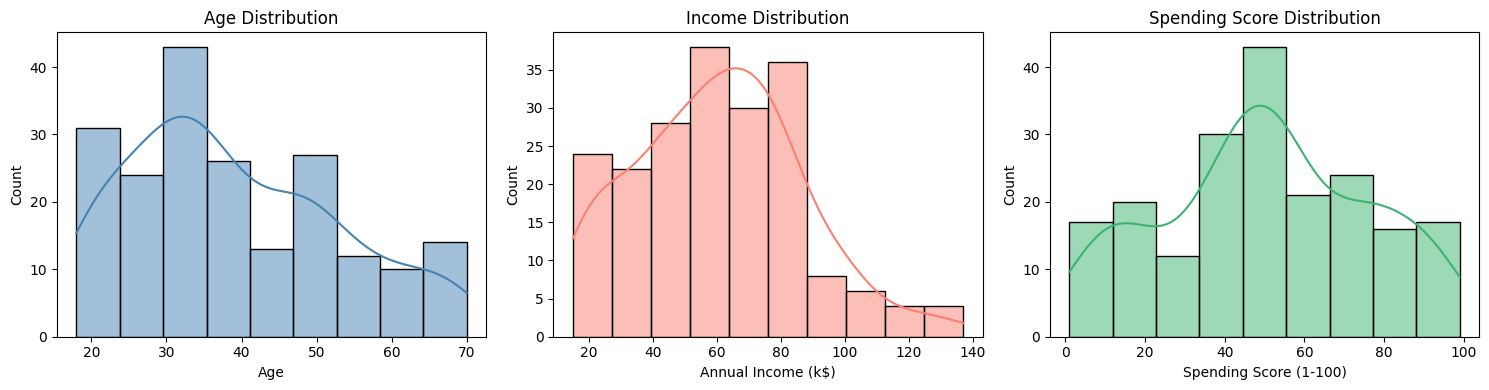

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['Age'], ax=axes[0], kde=True, color='steelblue')
axes[0].set_title('Age Distribution')

sns.histplot(df['Annual Income (k$)'], ax=axes[1], kde=True, color='salmon')
axes[1].set_title('Income Distribution')

sns.histplot(df['Spending Score (1-100)'], ax=axes[2], kde=True, color='mediumseagreen')
axes[2].set_title('Spending Score Distribution')

plt.tight_layout()
plt.show()

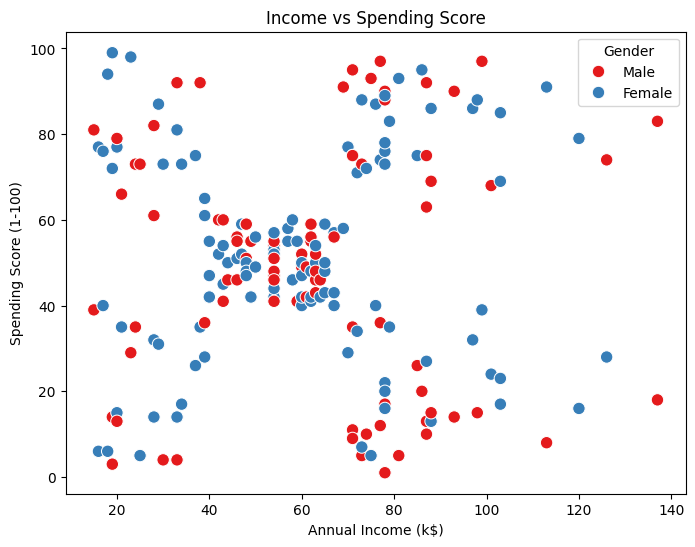

In [8]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Gender',
    palette='Set1',
    s=80
)
plt.title('Income vs Spending Score')
plt.show()

In [9]:
from sklearn.preprocessing import StandardScaler

# We use only Income and Spending Score for 2D clustering (easier to visualize)
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling - Income range:", X[:, 0].min(), "to", X[:, 0].max())
print("After scaling - Income range:", X_scaled[:, 0].min().round(2), "to", X_scaled[:, 0].max().round(2))

Before scaling - Income range: 15 to 137
After scaling - Income range: -1.74 to 2.92


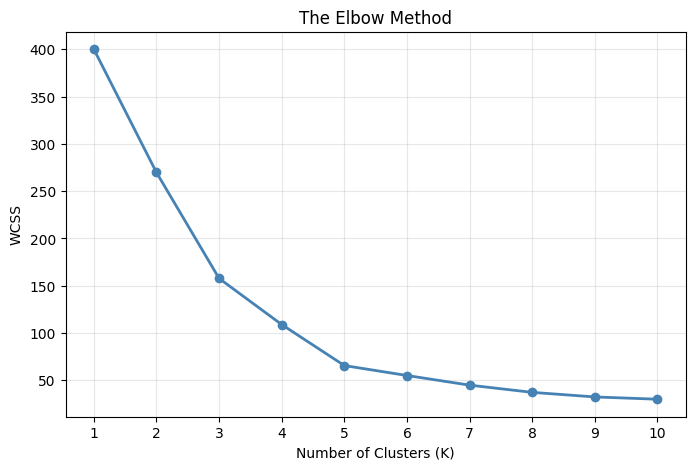

In [10]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', color='steelblue', linewidth=2)
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
# Train final K-Means model with K=5
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Assign cluster labels back to original dataframe
df['Cluster'] = kmeans.labels_

# See how many customers fall in each cluster
print(df['Cluster'].value_counts().sort_index())

# Look at the cluster centers (in scaled space)
print("\nCluster Centers (scaled):")
print(kmeans.cluster_centers_)

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

Cluster Centers (scaled):
[[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]


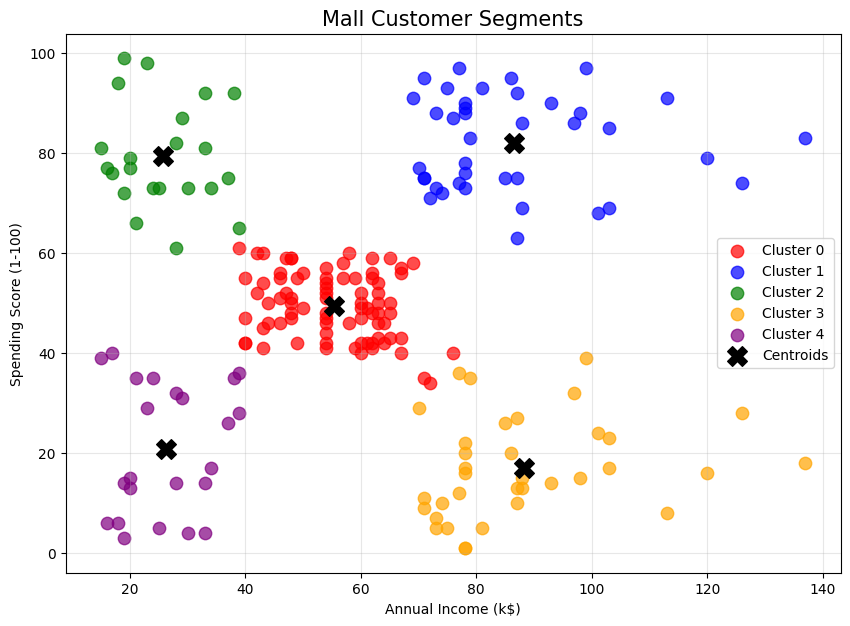

In [12]:
# Define colors for each cluster
colors = ['red', 'blue', 'green', 'orange', 'purple']

plt.figure(figsize=(10, 7))

# Plot each cluster separately
for i in range(5):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(
        cluster_data['Annual Income (k$)'],
        cluster_data['Spending Score (1-100)'],
        c=colors[i],
        label=f'Cluster {i}',
        s=80,
        alpha=0.7
    )

# Plot centroids in ORIGINAL space
# We need to inverse transform the scaled centers back to original scale
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centers_original[:, 0],
    centers_original[:, 1],
    c='black',
    marker='X',
    s=200,
    label='Centroids',
    zorder=5
)

plt.title('Mall Customer Segments', fontsize=15)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
# See the average Income and Spending Score per cluster
cluster_summary = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
print(cluster_summary)

          Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                  
0        42.7                55.3                    49.5
1        32.7                86.5                    82.1
2        25.3                25.7                    79.4
3        41.1                88.2                    17.1
4        45.2                26.3                    20.9


In [14]:
# Let's formally verify your age observation
print(df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1))

          Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                  
0        42.7                55.3                    49.5
1        32.7                86.5                    82.1
2        25.3                25.7                    79.4
3        41.1                88.2                    17.1
4        45.2                26.3                    20.9


In [15]:
# Final Business Summary
summary = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 
                                  'Spending Score (1-100)']].mean().round(1)

segment_names = {
    0: 'Average Joes',
    1: 'Target Customers', 
    2: 'Impulsive Spenders',
    3: 'Cautious Rich',
    4: 'Budget Conscious'
}

summary['Segment Name'] = summary.index.map(segment_names)
summary['Marketing Strategy'] = [
    'Seasonal promotions, mid-range products',
    'VIP loyalty programs, premium brands',
    'Flash sales, FOMO marketing',
    'Luxury experiences, quality campaigns',
    'Value deals, combo offers'
]

print(summary)

          Age  Annual Income (k$)  Spending Score (1-100)        Segment Name  \
Cluster                                                                         
0        42.7                55.3                    49.5        Average Joes   
1        32.7                86.5                    82.1    Target Customers   
2        25.3                25.7                    79.4  Impulsive Spenders   
3        41.1                88.2                    17.1       Cautious Rich   
4        45.2                26.3                    20.9    Budget Conscious   

                              Marketing Strategy  
Cluster                                           
0        Seasonal promotions, mid-range products  
1           VIP loyalty programs, premium brands  
2                    Flash sales, FOMO marketing  
3          Luxury experiences, quality campaigns  
4                      Value deals, combo offers  
